# Chapter 2: Bayesian Computation

In [6]:
#import sys
#!{sys.executable} -m pip install pymc
#!{sys.executable} -m pip install preliz

## Exercise 1

## Non-Markovian methods: Grid computing

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm

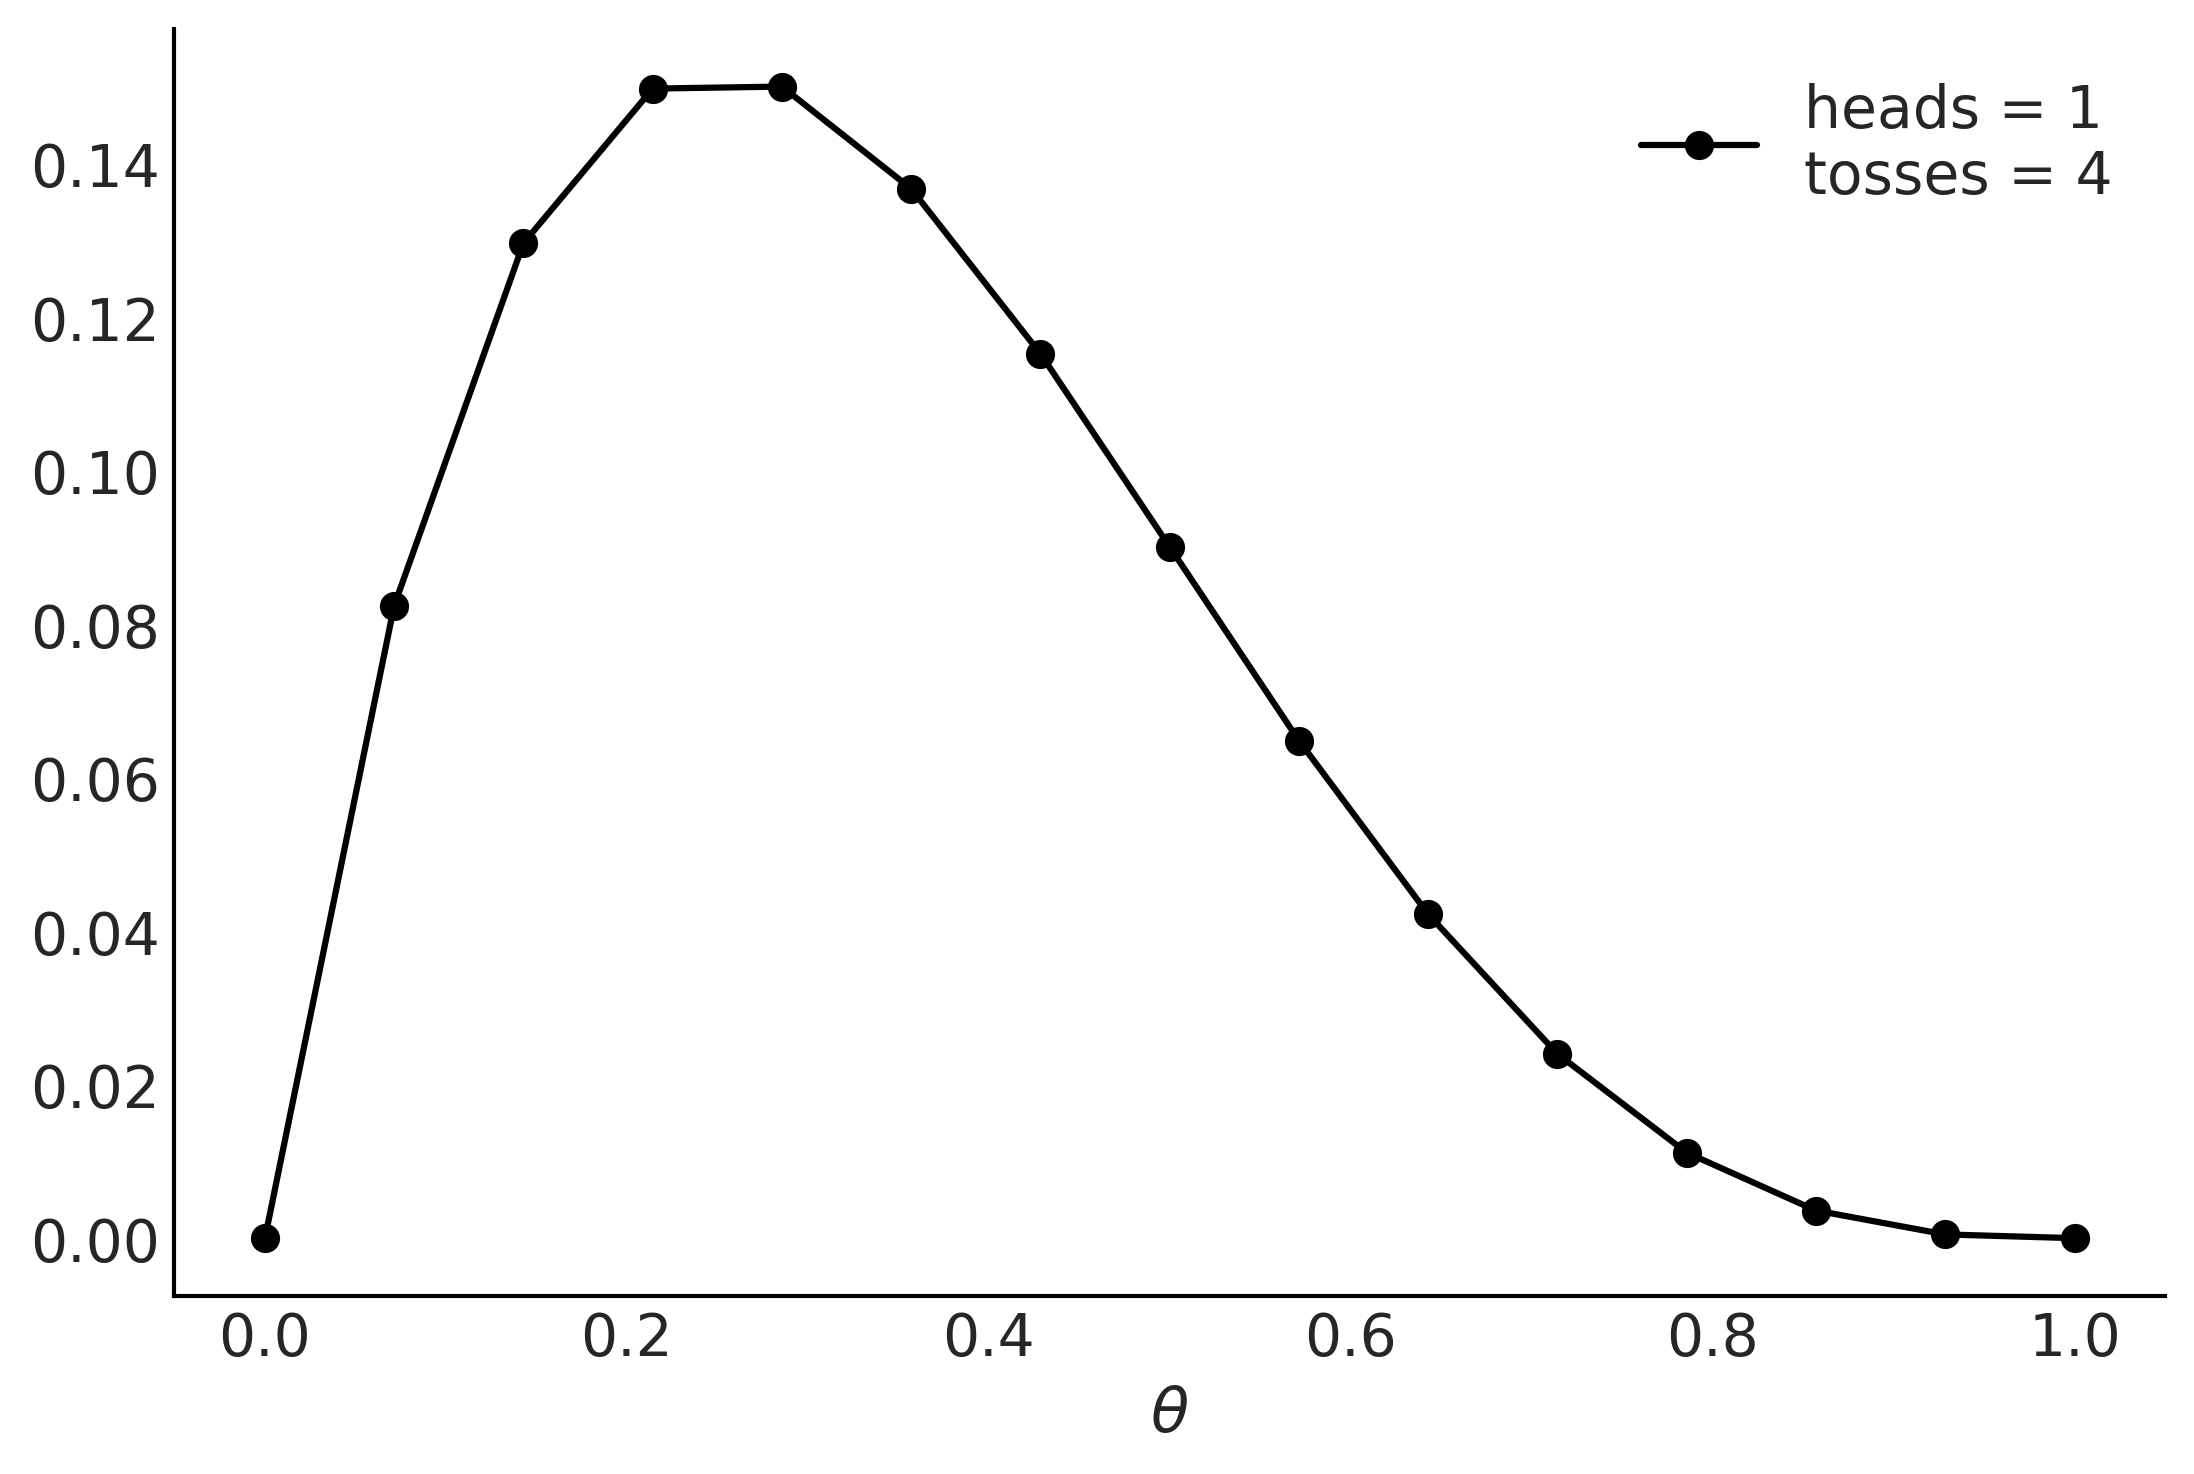

In [49]:
def posterior_grid(grid_points=100, heads=6, tosses=9):
    grid = np.linspace(0, 1, grid_points)
    prior = np.repeat(5, grid_points)
    likelihood = stats.binom.pmf(heads, tosses, grid)
    unstd_posterior = likelihood * prior
    posterior = unstd_posterior / unstd_posterior.sum()
    return grid, posterior

points = 15
h, n = 1, 4

grid, posterior = posterior_grid(points, h, n)

plt.plot(grid, posterior, 'o-', label=f'heads = {h}\ntosses = {n}')
plt.xlabel(r'$\theta$')
plt.legend(loc=0)
plt.show()

## Exercise 2: Monte Carlo

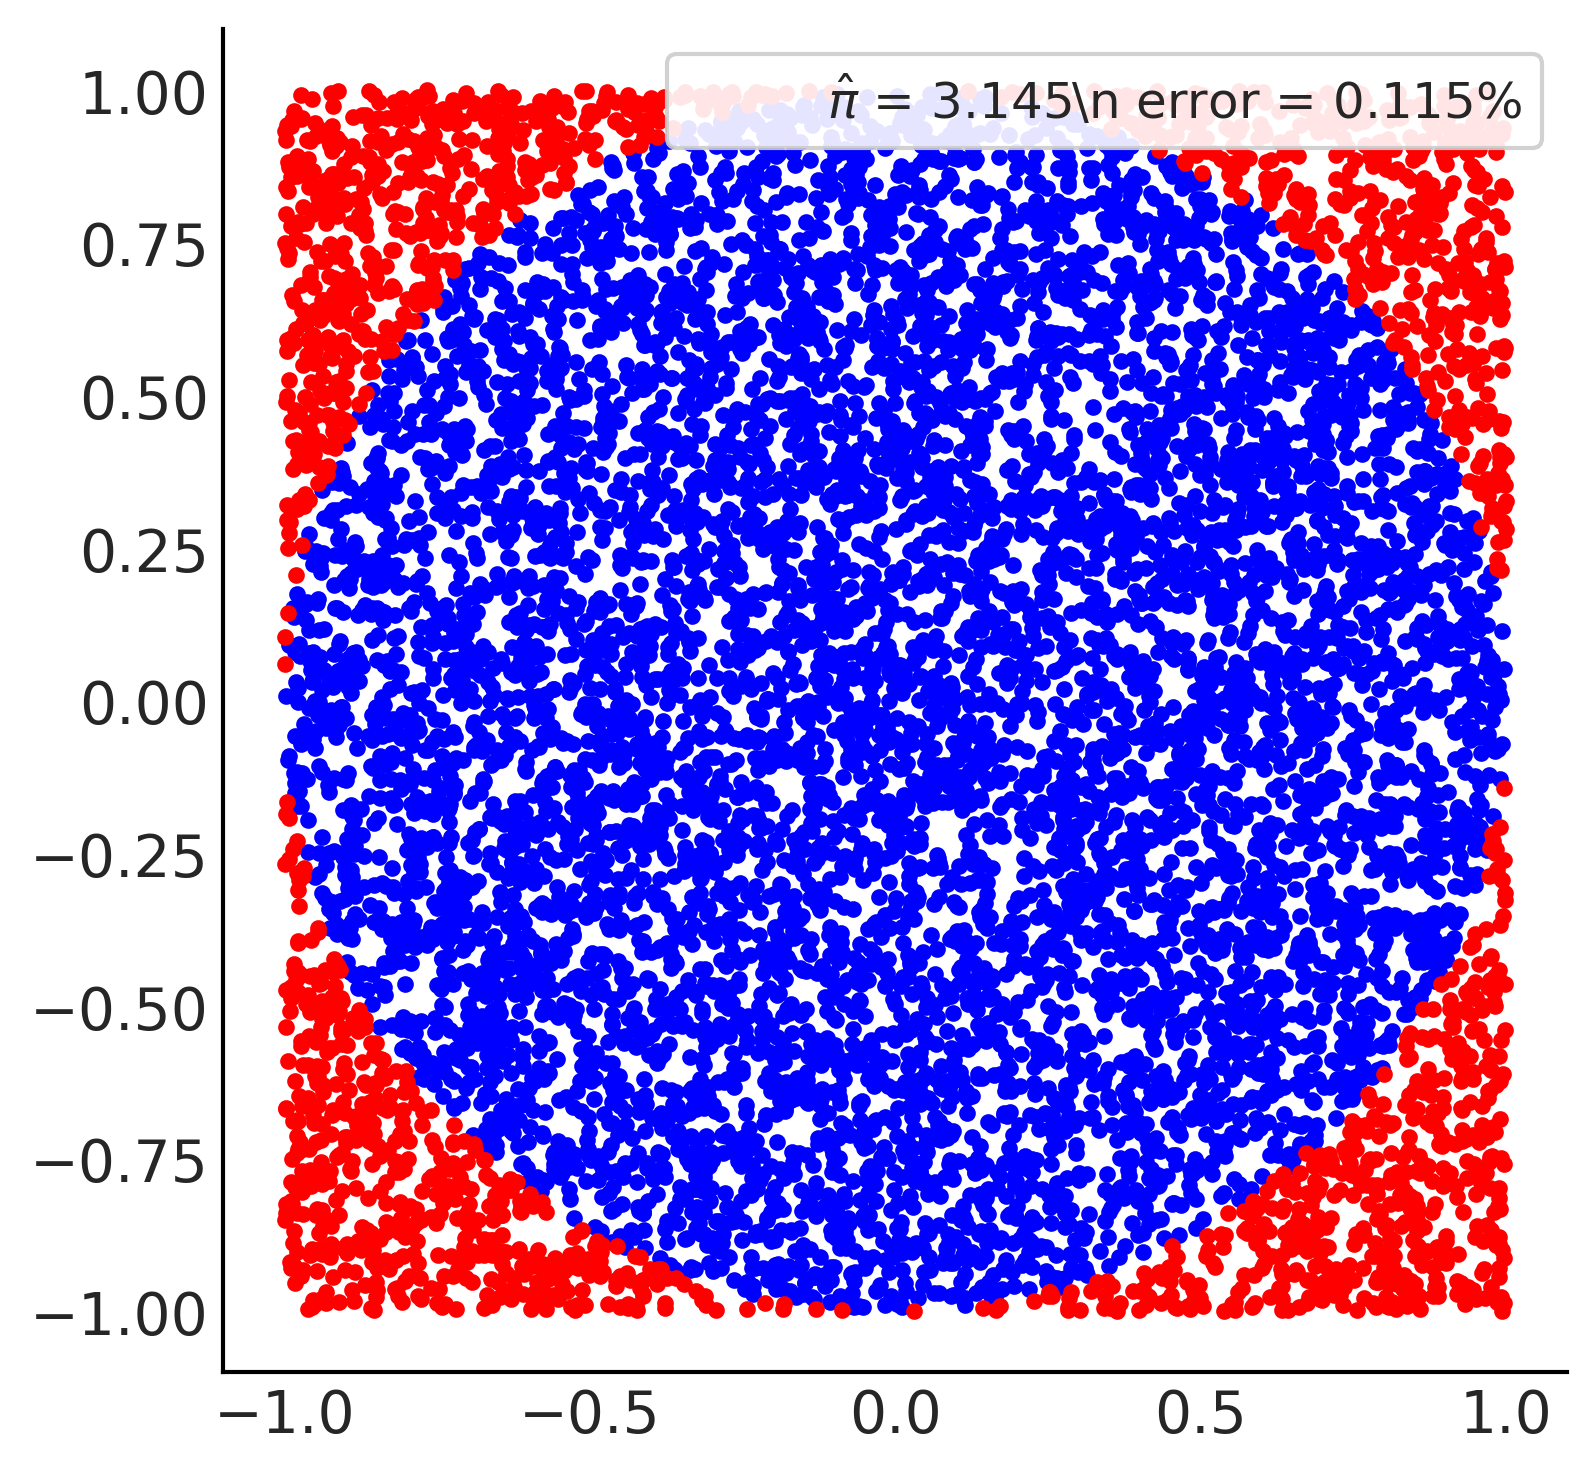

In [62]:
N = 10000
x, y = np.random.uniform(-1, 1, size=(2, N))
inside = (x**2 + y**2)  <= 1
pi = inside.sum()*4/N
error = abs((pi - np.pi)/pi)* 100
outside = np.invert(inside)
plt.plot(x[inside], y[inside], 'b.')
plt.plot(x[outside], y[outside], 'r.')
plt.plot(0, 0, 
         label=r'$\hat \pi$ = {:4.3f}\n error = {:4.3f}%'.format(pi, error), 
         alpha=0)
plt.axis('square')
plt.legend(frameon=True, framealpha=0.9, fontsize=12);

## Exercise 3 : Metropolis-Hastings

The following code shows a very simple implementation of the Metropolis algorithm. It is not designed to solve a real problem, but to demonstrate that we can generate samples from a function as long as we can compute its value at a given point. This example is not Bayesian, since it does not use prior information or data. It highlights that MCMC methods are general and can be applied in many different areas. For example, in fields like physics, instead of working with probabilities, we might use a function that measures the energy of a system.

In this code, the input to the metropolis function is a SciPy distribution. We assume that we cannot directly generate random samples from it. However, we can still compute the height (probability value) of the distribution at any point using pdf().

We are NOT directly getting random samples.

Instead we are only checking: "Is this point high or low on the curve?"

Why this is enough for Metropolis

Metropolis only needs to compare two points:

Is $x_{i+1}$ better than $x_i$

We check:

pdf($x_{i+1}$) vs pdf($x_i$)

So even without knowing the full distribution, we can compare probabilities locally decide whether to move or stay

In [63]:
def metropolis(func, steps=10000):
    """A very simple Metropolis implementation"""
    samples = np.zeros(steps)
    old_x = func.mean()
    old_prob = func.pdf(old_x)
    for i in range(steps):
        new_x = old_x + np.random.normal(0, 0.5)
        new_prob = func.pdf(new_x)
        acceptance = new_prob/old_prob
        if acceptance >= np.random.random():
            samples[i] = new_x
            old_x = new_x
            old_prob = new_prob
        else:
            samples[i] = old_x
    return samples

We use the Beta distribution only as a known reference so that we can compare it with the samples generated by the Metropolis algorithm. The Beta pdf() gives the exact true distribution, while the Metropolis algorithm produces an approximation using samples. By plotting both together, we can visually check how closely the sampled values match the true distribution.

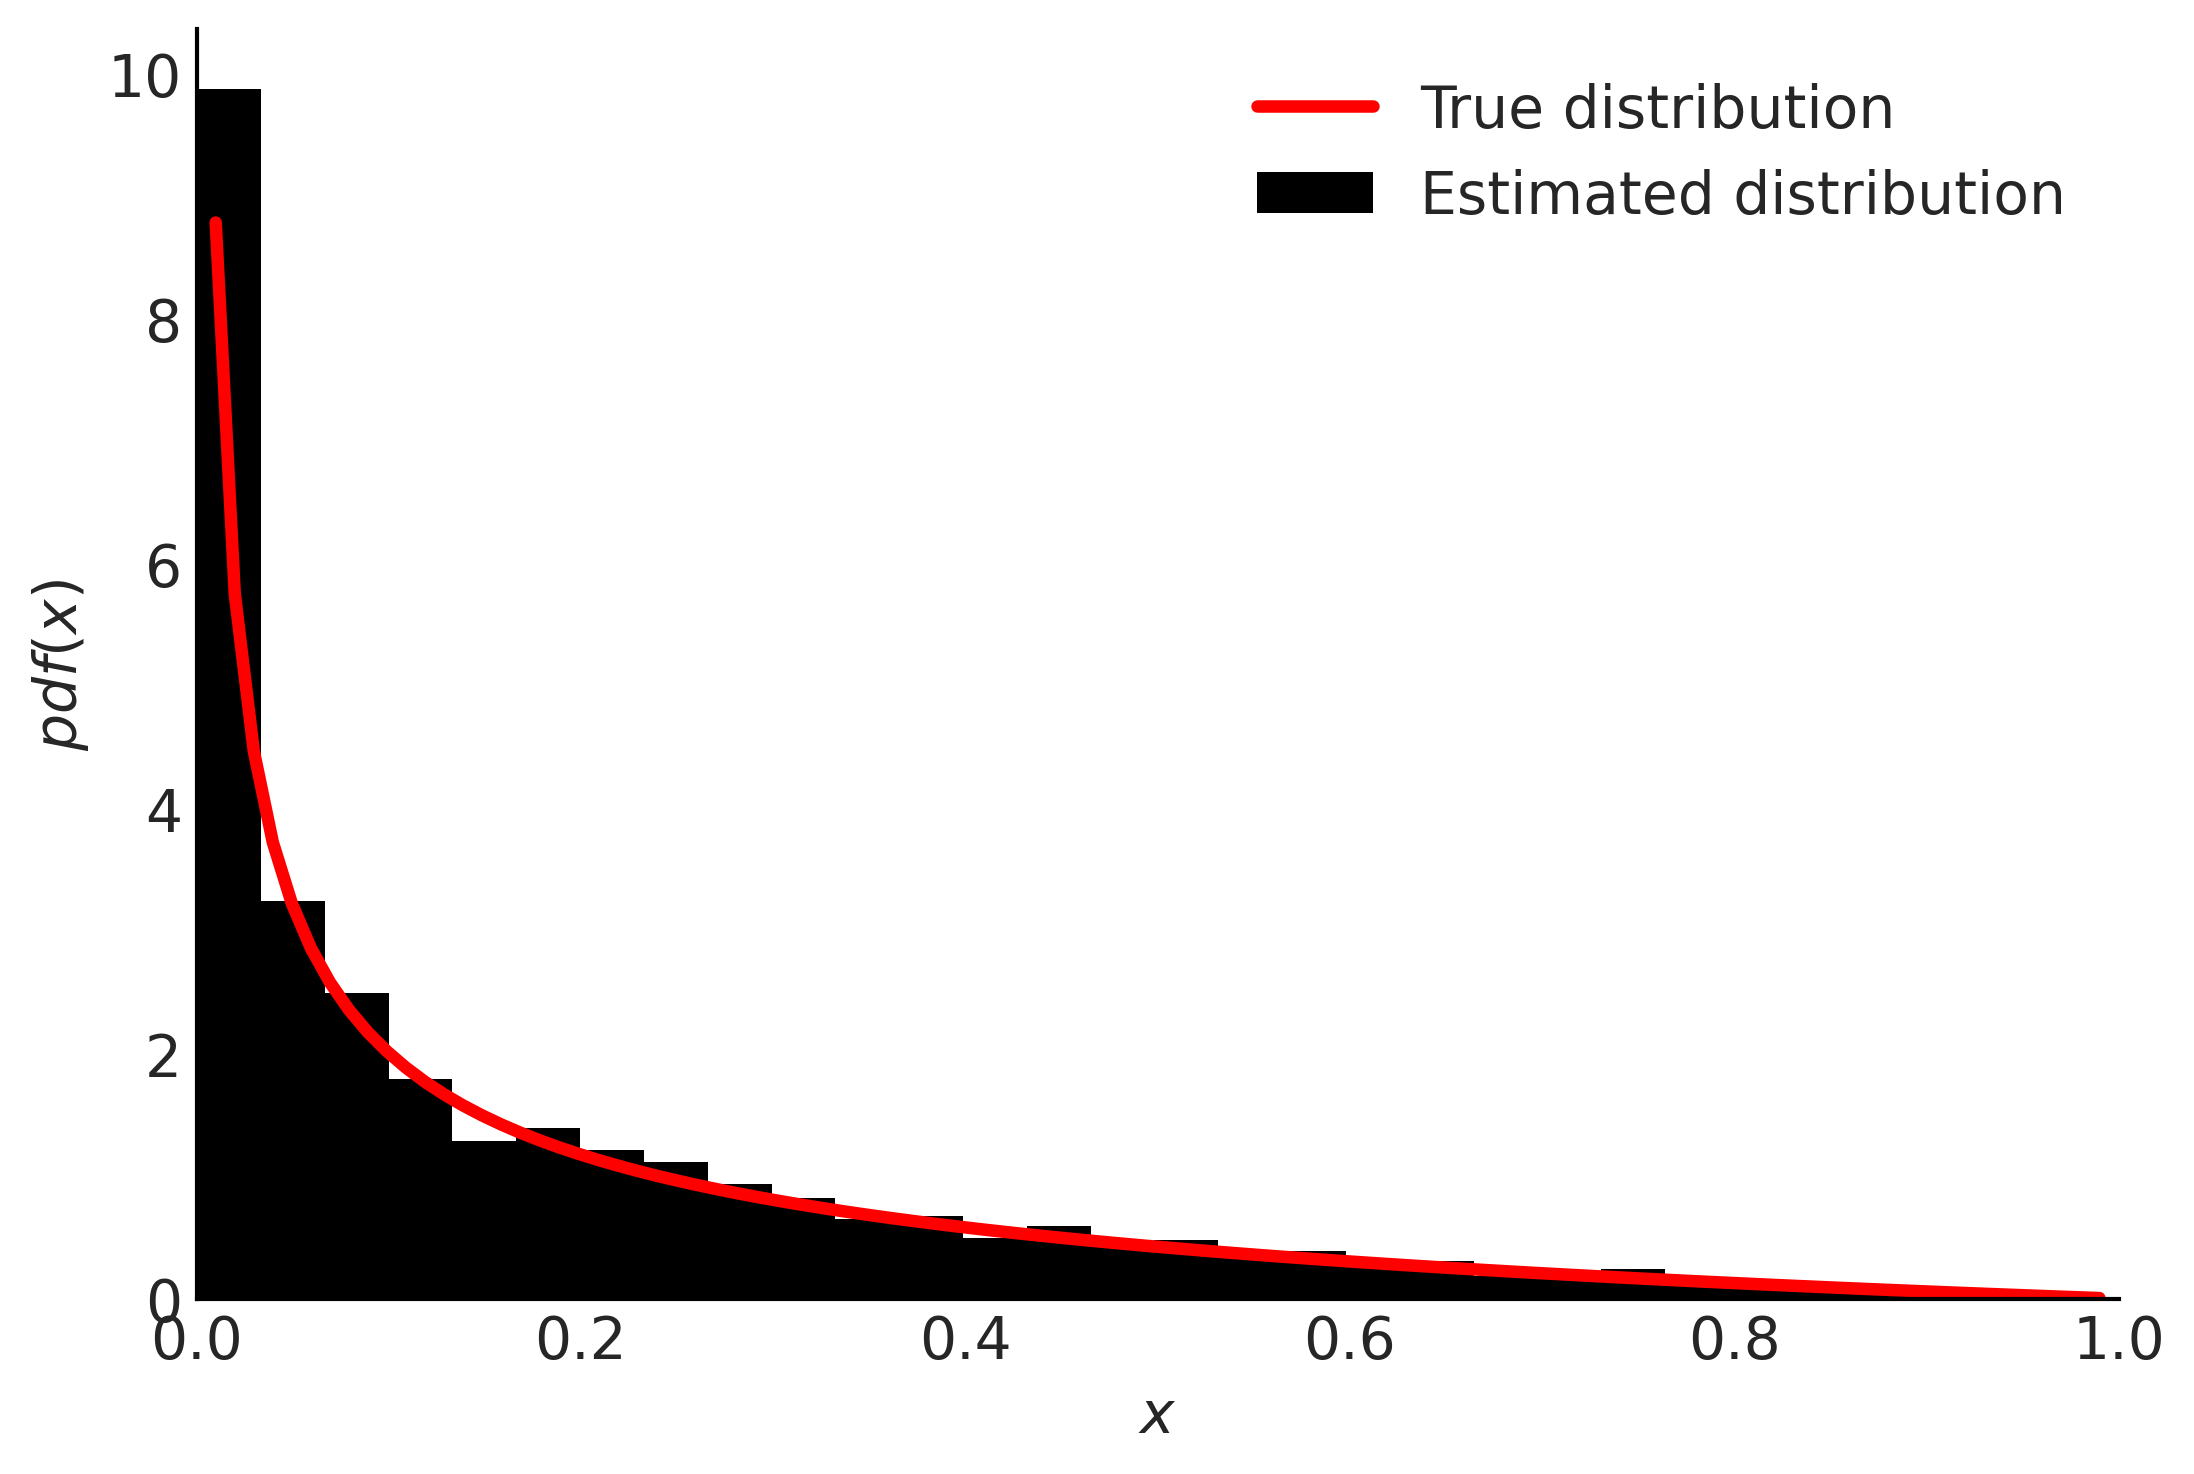

In [64]:
func = stats.beta(0.4, 2)
samples = metropolis(func=func)

x = np.linspace(0.01, .99, 100)
y = func.pdf(x)

plt.xlim(0, 1)
plt.plot(x, y, 'r-', lw=3, label='True distribution')
plt.hist(samples, bins=30, density=True, label='Estimated distribution')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$pdf(x)$', fontsize=14)
plt.legend(fontsize=14)
plt.show()

Example 

We toss a coin a few times and observe the outcomes. The probability of getting a head is unknown, and we want to estimate this probability, denoted by $\theta$, while also quantifying how uncertain we are about it. Instead of treating $\theta$ as a fixed but unknown number, the Bayesian approach treats it as a random variable and updates our belief about it after observing data.

In [34]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

- NumPy: Handles numerical computations. It is used to create arrays (like coin toss data), generate grids of values
- Pandas: Manages and organizes data in table form.
- Matplotlib: Creates visualizations. It is used to plot posterior distributions, trace plots, and other graphs to understand results and uncertainty.
- PyMC: Builds and fits Bayesian models. It defines priors (e.g., for θ), likelihoods (e.g., Bernoulli for coin tosses), and performs sampling (MCMC) to obtain the posterior distribution.
- ArviZ: Analyzes Bayesian results. It provides tools for diagnostics (trace plots), summaries (mean, HDI), and posterior visualizations.
- Preliz: Helps define and explore probability distributions. It is used here to simulate data (e.g., generating Bernoulli/Binomial outcomes) and visualize distributions easily.

In [35]:
# controlling how your plots look
az.style.use("arviz-grayscale")
from cycler import cycler
default_cycler = cycler(color=["#000000", "#6a6a6a", "#bebebe", "#2a2eec"])
plt.rc('axes', prop_cycle=default_cycler)
plt.rc('figure', dpi=300)

In [36]:
np.random.seed(234)
trials = 4
theta_real = 0.35 # unknown value in a real experiment
data = pz.Binomial(n=1, p=theta_real).rvs(trials)
data

array([1, 0, 0, 0])

- In real problems, data is given
- Here we simulate data to understand the method

- Here We assume a true probability: θ = 0.35
- Generate 4 Bernoulli trials:

1 = success
0 = failure

- Observed: 1 success out of 4 trials
- This is **all the information** we will use

- Important: In real life, θ is unknown. But here we are pretending not to know it.

We must define:
- Prior → what we believe before seeing data
- Likelihood → how data is generated

- θ ~ Beta(1,1) → uniform prior (no preference)
- y ~ Bernoulli(θ) → data model

Interpretation:

Before data: all θ values equally likely

After data: beliefs will update

In [37]:
# Model Specification (Bayesian Model)
with pm.Model() as our_first_model:
    θ = pm.Beta('θ', alpha=1., beta=1.)
    y = pm.Bernoulli('y', p=θ, observed=data)
    idata = pm.sample(1000, random_seed=4591) # Posterior Sampling

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [θ]


C:\Users\B1500\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


- Posterior is often not analytically solvable
- Here we use MCMC (NUTS) to approximate it
- Generates samples from posterior distribution of θ
- These samples represent plausible values of θ

array([[<Axes: title={'center': 'θ'}>, <Axes: title={'center': 'θ'}>]],
      dtype=object)

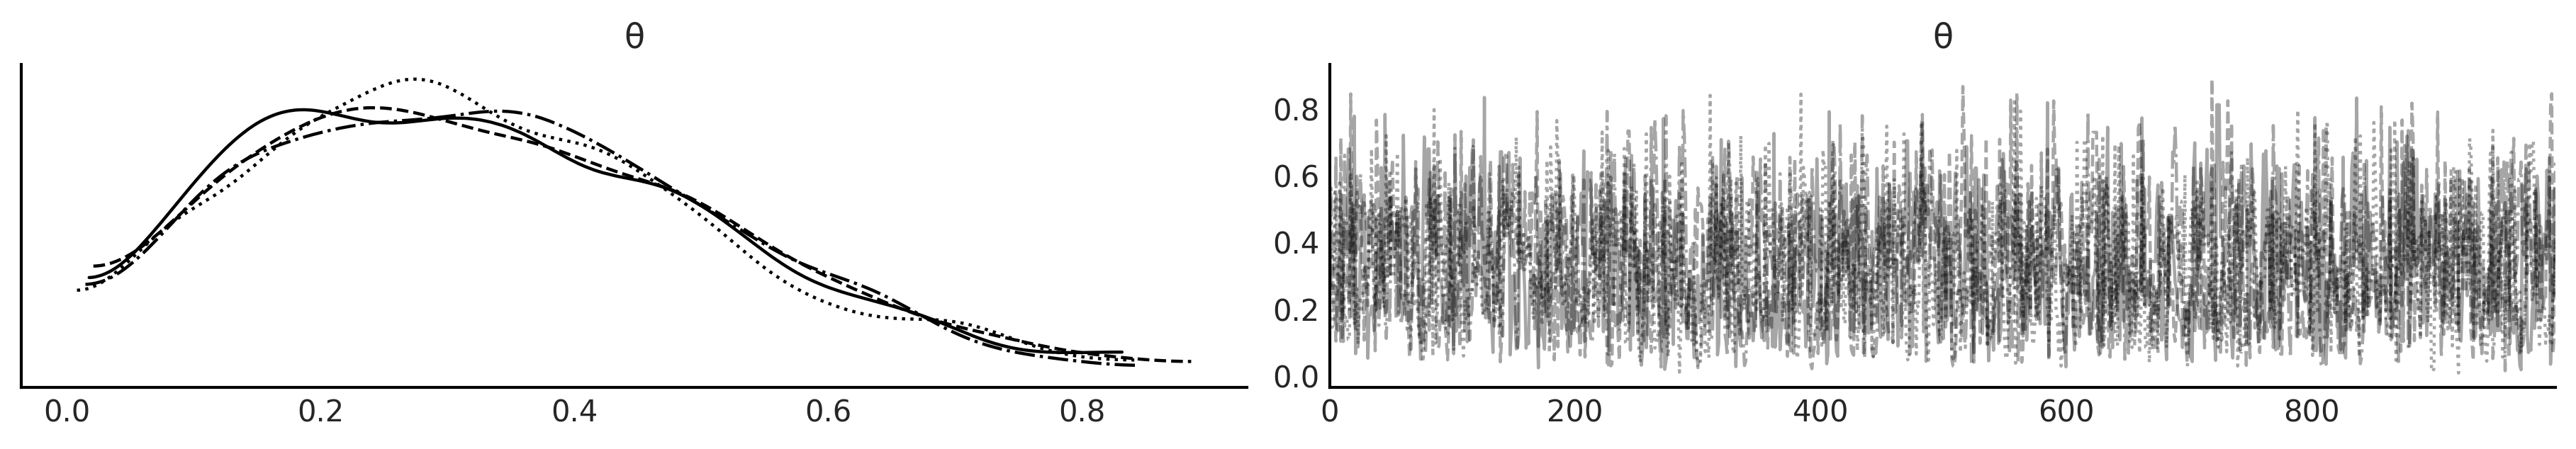

In [38]:
az.plot_trace(idata)

On the left side, you see the posterior distribution of the parameter, usually shown as a kernel density estimate (KDE). This is a smooth curve that summarizes all the sampled values.  hTis represents the combined information from all chains after sampling. The interpretation here focuses on where the parameter values are concentrated and how uncertain the estimate is. It tells you where the parameter values are concentrated after observing the data. Peaks in this plot indicate the most probable values of the parameter, while the spread of the curve reflects the level of uncertainty. A narrow curve suggests high confidence, whereas a wider curve indicates greater uncertainty.

On the right side, the trace plot shows the sampled values of the parameter across iterations for each chain. Each chain is displayed as a separate line. The interpretation here is about convergence and mixing. If the chains overlap and fluctuate randomly around the same region without trends or separation, it indicates that the sampler has converged and is exploring the same posterior distribution across chains. If the chains appear separated, drift over time, or show patterns, it may indicate convergence issues or poor mixing.

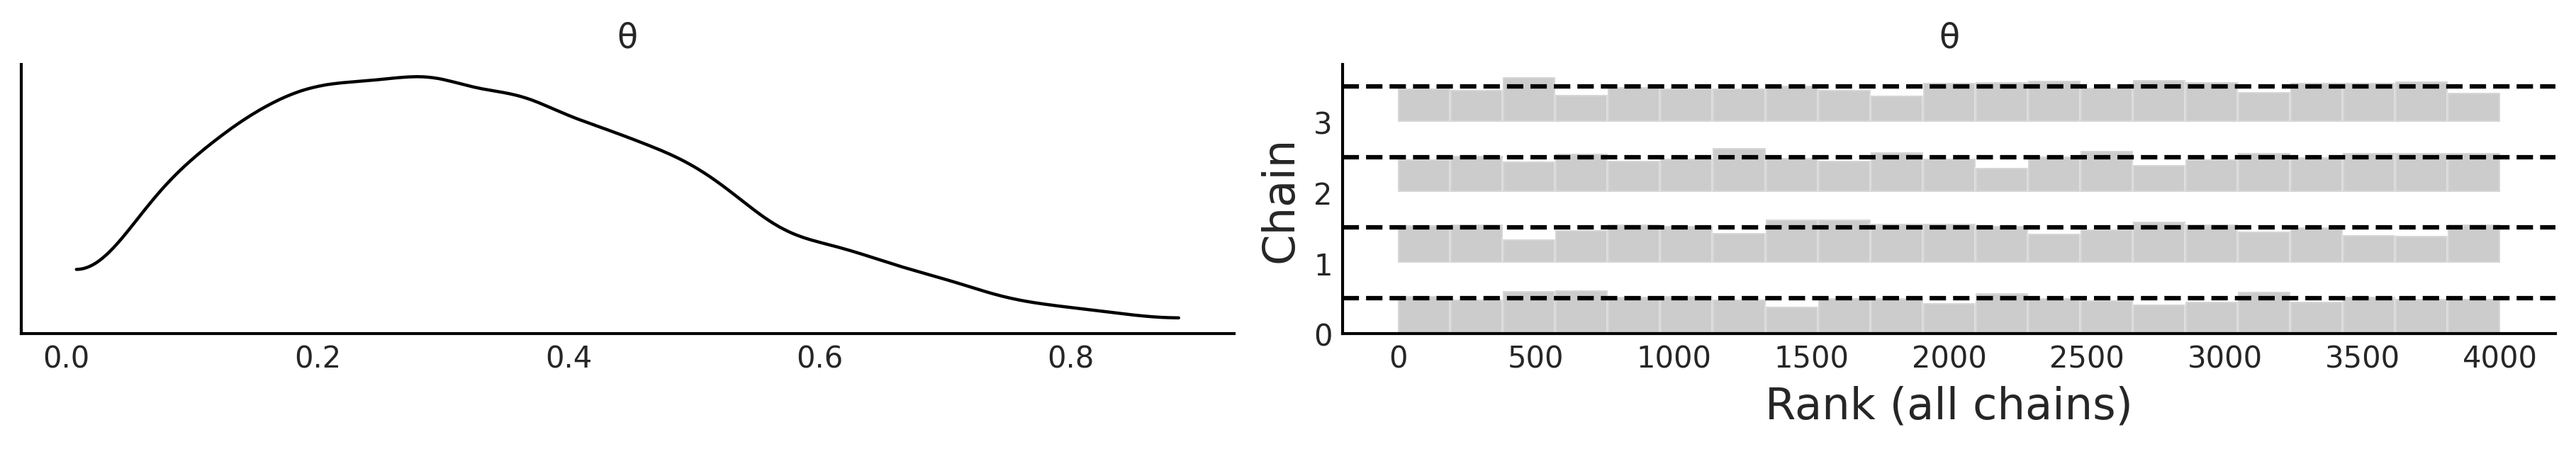

In [39]:
az.plot_trace(idata, kind="rank_bars", combined=True, rank_kwargs={"colors": "k"});

On the left side, you still see a single KDE curve. This represents the posterior distribution of the parameter, but now it is computed by combining samples from all chains together (because combined=True). Since all chains are merged, only one smooth density curve is shown instead of separate chain-wise distributions. This KDE tells you where the parameter values are concentrated overall and reflects the final posterior estimate after using all available samples.

On the right side, you see rank histograms rather than the usual trace lines. Each chain contributes a histogram of its ranked samples, and these are overlaid. The idea is that if all chains are sampling from the same posterior distribution and are well mixed, their rank distributions should look similar and roughly uniform across the bins. The separate histogram layers help you compare how each chain contributes across the range of values, but they are not showing iteration-by-iteration traces.

In [40]:
az.summary(idata, kind="stats").round(2)

,mean,sd,hdi_3%,hdi_97%
θ,0.33,0.17,0.02,0.63


This table is a posterior summary of the parameter θ (the probability of getting heads in your coin example).

mean = 0.34
This is the average of all sampled posterior values of θ. It can be interpreted as a point estimate of the probability of heads given the data and prior.

sd = 0.18
This is the standard deviation of the posterior samples. It reflects the uncertainty in the estimate. A relatively large value (like 0.18) indicates that there is still considerable uncertainty about the true value of θ, which is expected since the dataset is small (only 4 trials).

hdi_3% = 0.04 and hdi_97% = 0.67
This interval is the Highest Density Interval (HDI). It represents the range where the most credible values of θ lie, covering approximately 94% of the posterior mass. In this case, the model suggests that θ is most likely between 0.04 and 0.67.

<Axes: title={'center': 'θ'}>

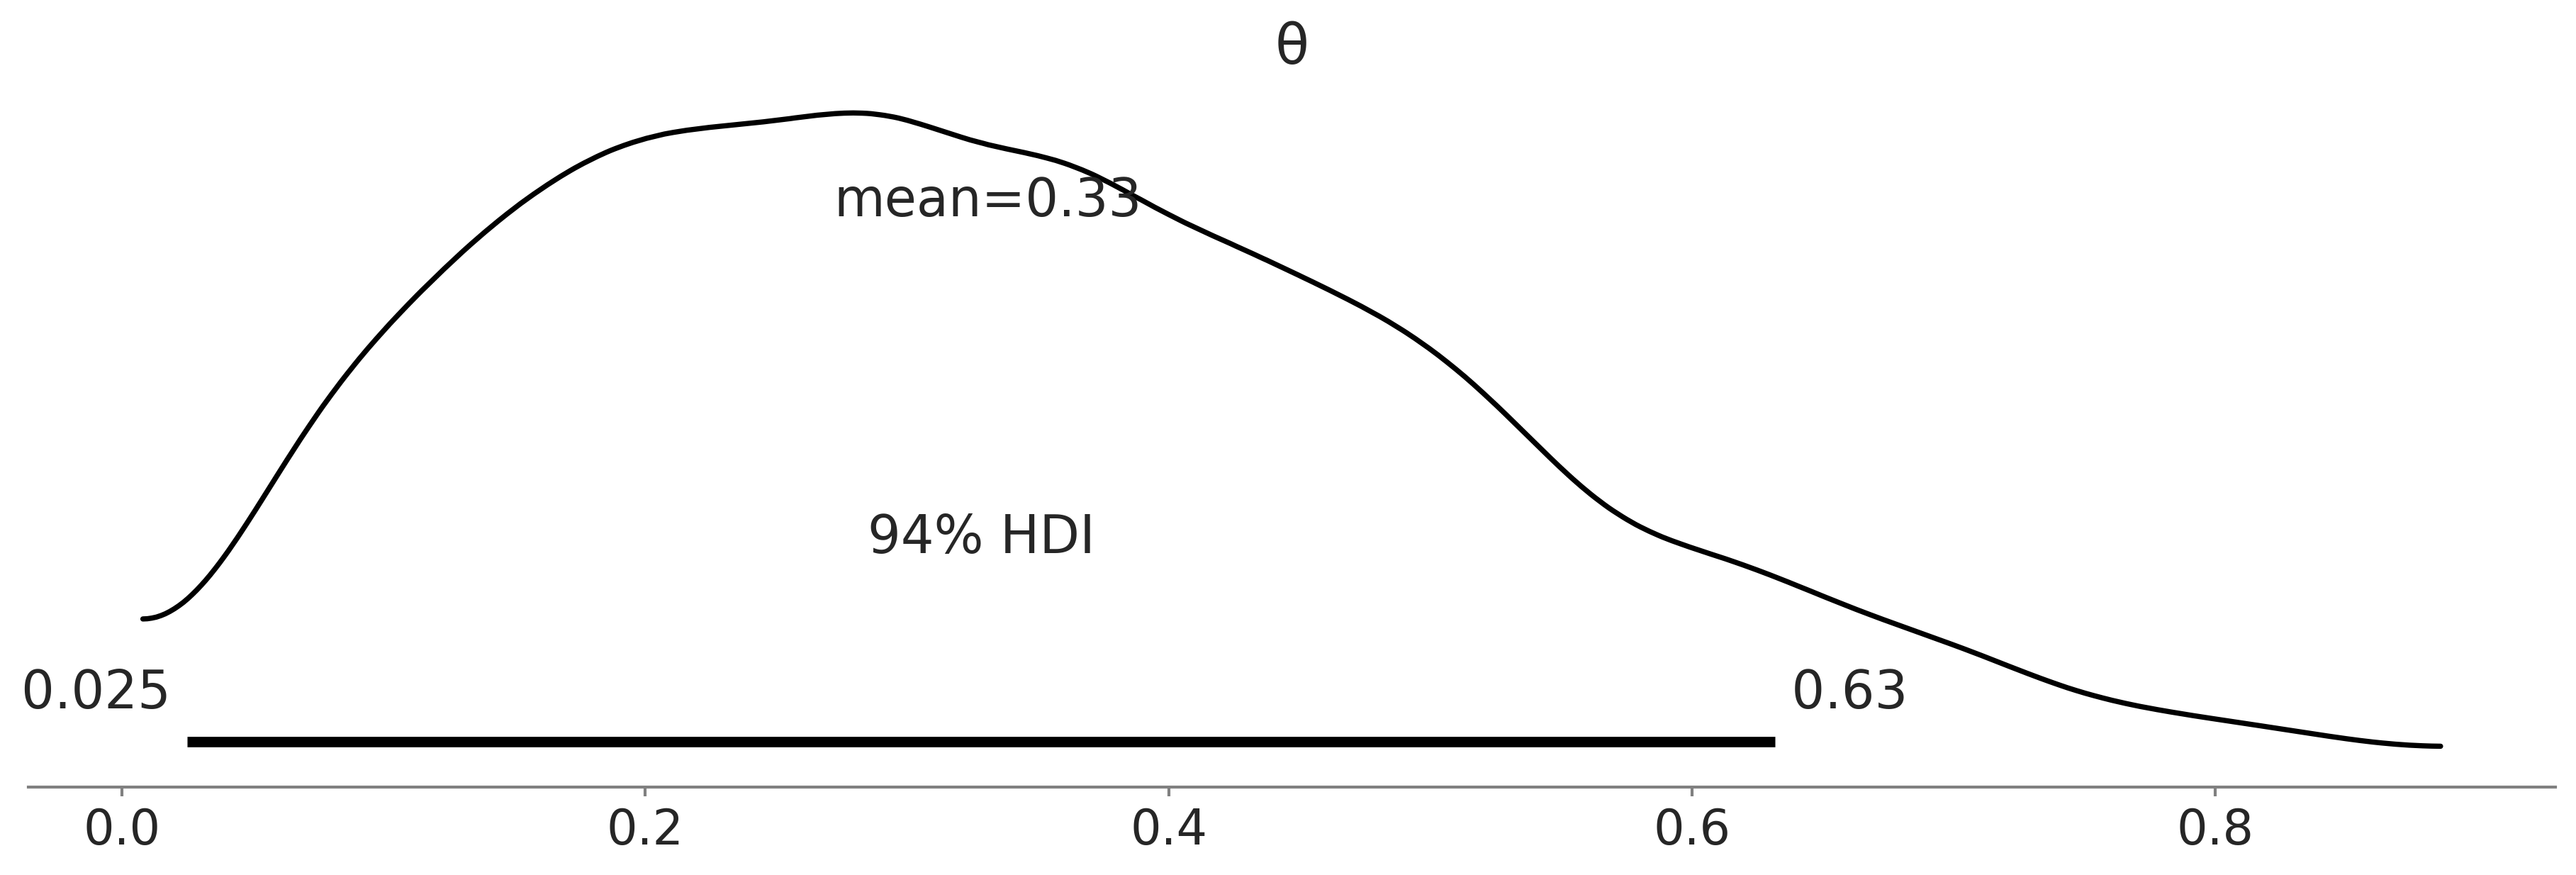

In [41]:
az.plot_posterior(idata, figsize=(12, 4))

This displays the posterior distribution of the parameter(s) as a smooth KDE curve based on all MCMC samples combined across chains. The curve shows where the parameter values are most concentrated after observing the data, with the peak indicating the most likely values. It also typically marks the mean and the Highest Density Interval (HDI), which represents the range of most credible values. In this example, the posterior is centered around the value near 0.34, indicating the estimated probability of heads, while the spread of the curve and the HDI (approximately 0.04 to 0.67) reflect the remaining uncertainty due to the small number of observations.

({'BF10': np.float64(0.7554381478062332),
  'BF01': np.float64(1.3237351104176645)},
 <Axes: title={'center': 'The BF_10 is 0.76\nThe BF_01 is 1.32'}, xlabel='θ', ylabel='Density'>)

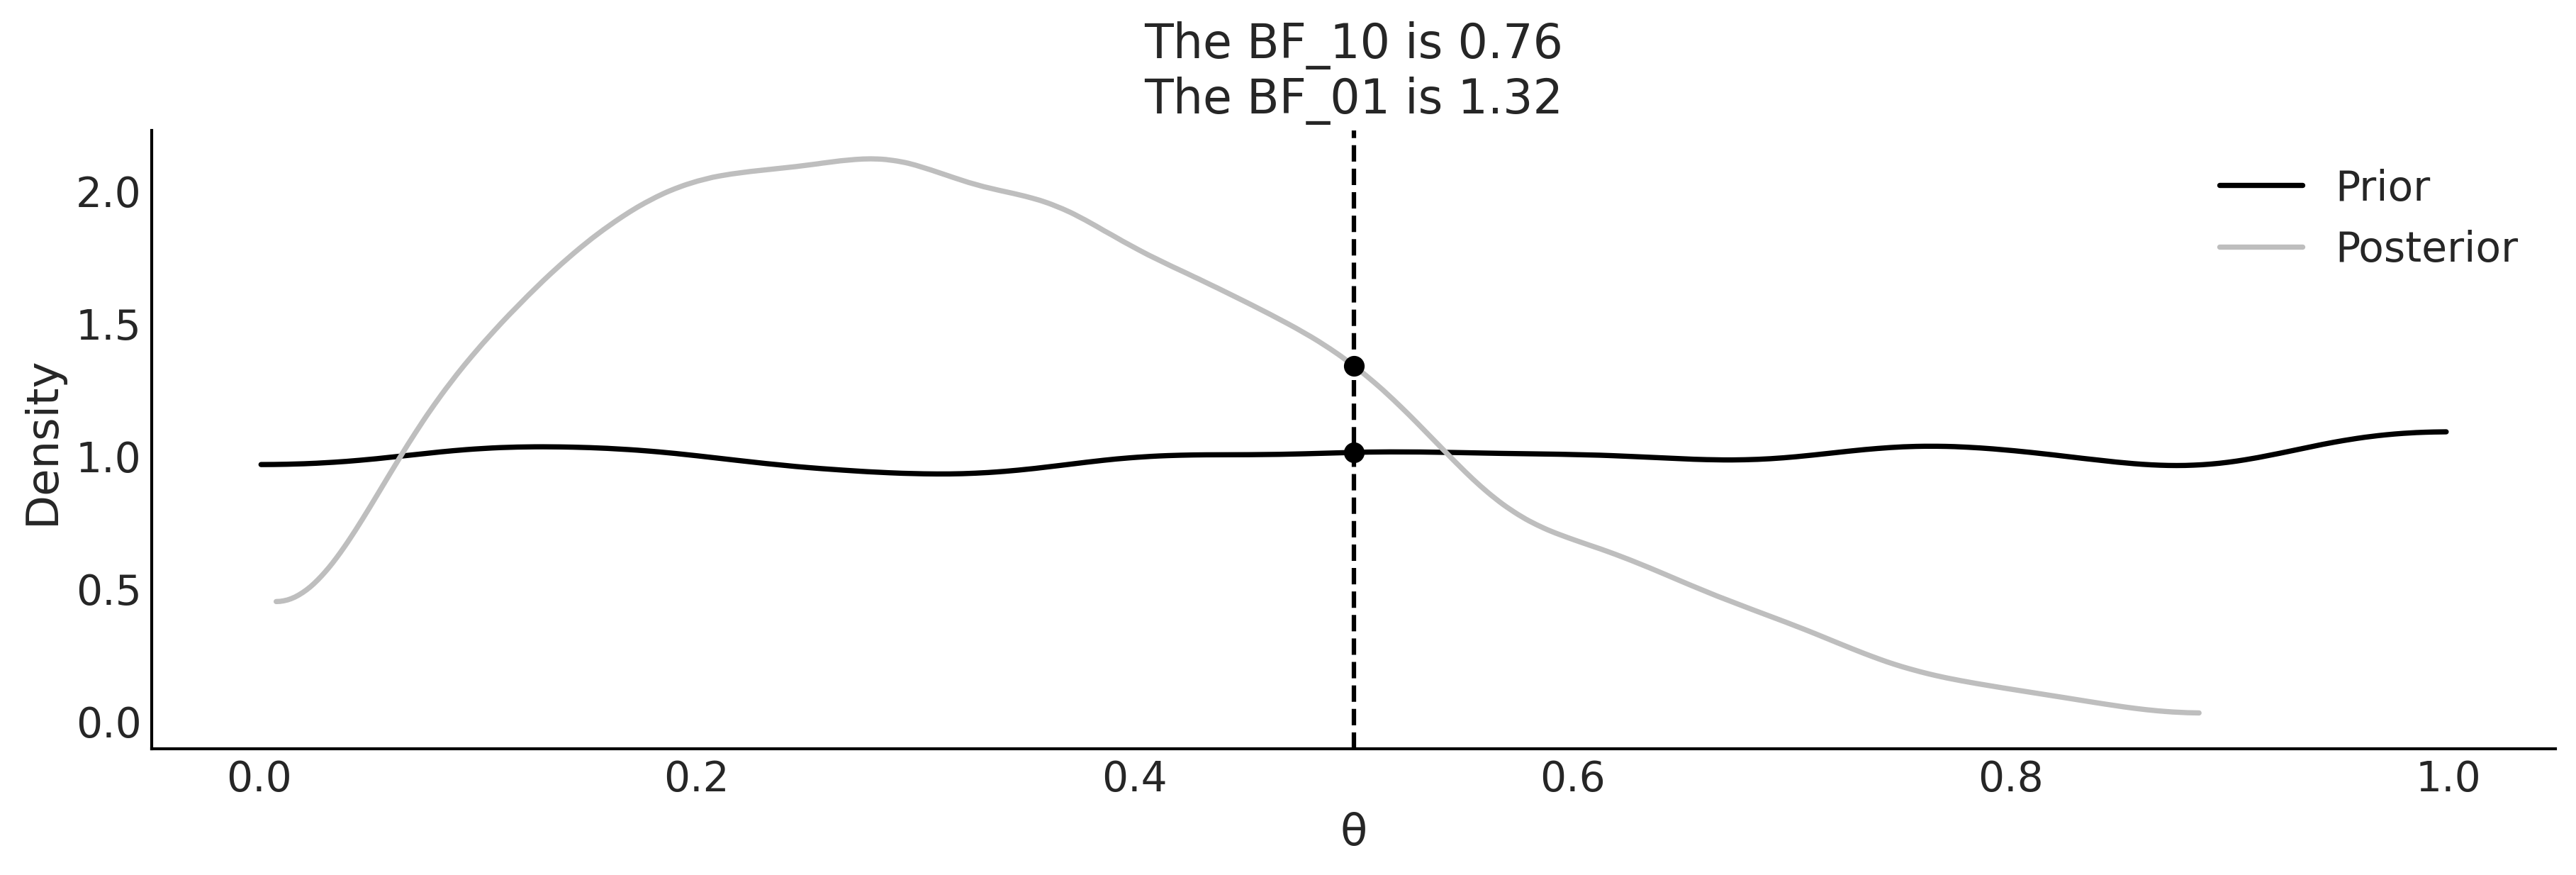

In [42]:
az.plot_bf(idata, var_name="θ", prior=np.random.uniform(0, 1, 10000), ref_val=0.5, figsize=(12, 4), colors=["C0", "C2"])

This is used to compare the posterior distribution of the parameter  θ with its prior distribution relative to a chosen reference value (here, 0.5). It visualizes how the observed data updates our belief about θ by showing both the prior and posterior distributions and highlighting how much probability mass lies on either side of the reference value. The reference value acts as a benchmark for a hypothesis, such as whether the coin is fair.

In this plot, the posterior distribution shows more mass to the left of 0.5, which indicates that values of θ less than 0.5 are more supported by the data. It suggests that the coin is likely biased toward tails, since the probability of heads is estimated to be below 0.5. Compared to the prior (which is uniform and does not favor any particular value), the posterior shifts toward lower values of θ, providing evidence against the hypothesis that the coin is fair

<Axes: title={'center': 'θ'}>

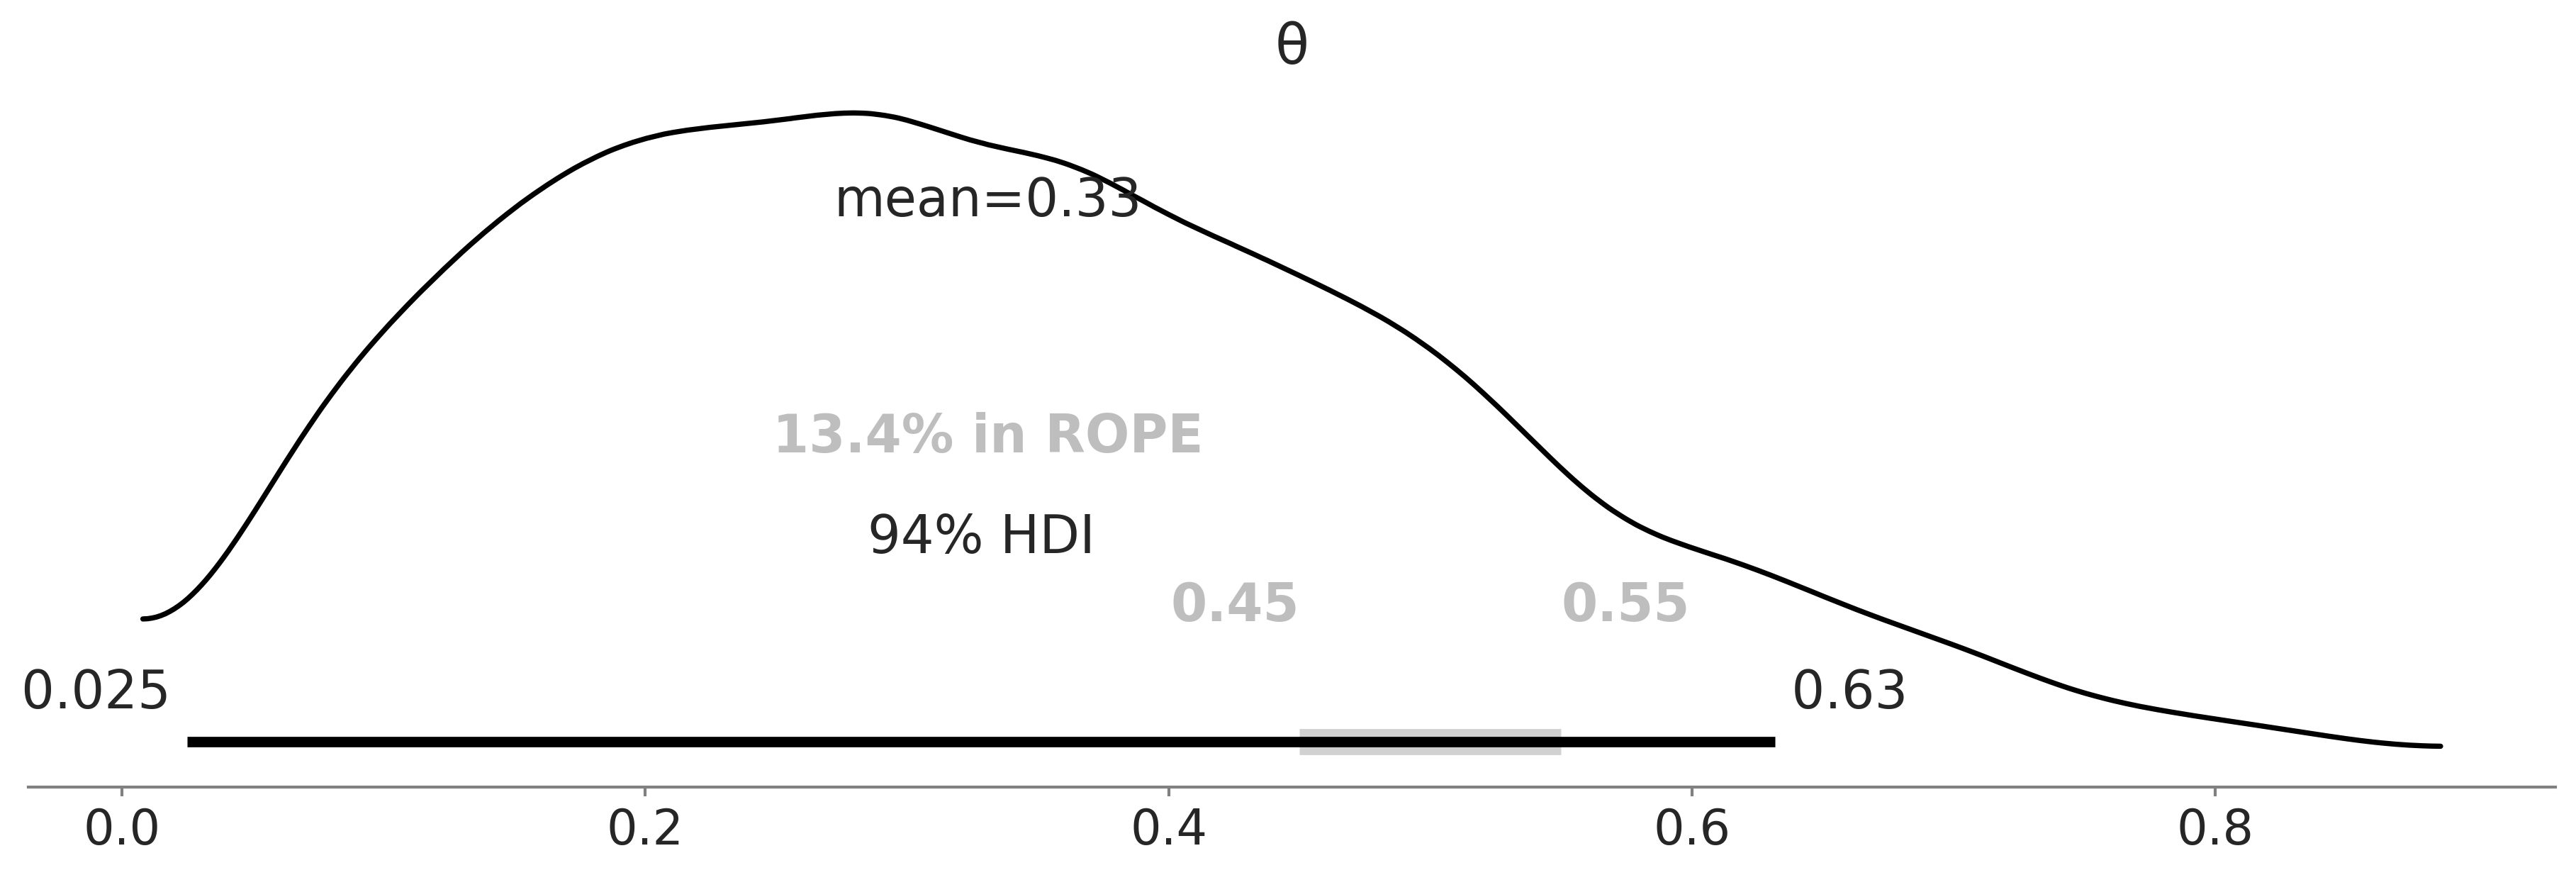

In [43]:
az.plot_posterior(idata, rope=[0.45, .55], figsize=(12, 4))

This plot visualizes the posterior distribution of the parameter θ along with a Region of Practical Equivalence (ROPE). The ROPE is the interval 
[0.45,0.55], which represents values that are considered practically equivalent to 0.5 (a fair coin) for decision-making purposes. The plot shows the posterior density curve and highlights how much of the distribution falls inside, below, or above this ROPE interval. This allows us to assess whether the parameter is meaningfully different from 0.5, rather than just statistically different.

In this example a large portion of the posterior lies outside the ROPE and more of it is concentrated below 0.45, it suggests that θ is likely less than 0.5 in a practically meaningful way, indicating a bias toward tails. If most of the posterior mass were inside the ROPE, it would suggest that the coin behaves approximately like a fair coin. If the posterior overlaps both inside and outside the ROPE, the evidence would be inconclusive, meaning the data does not strongly support a clear decision about fairness.

<Axes: title={'center': 'θ'}>

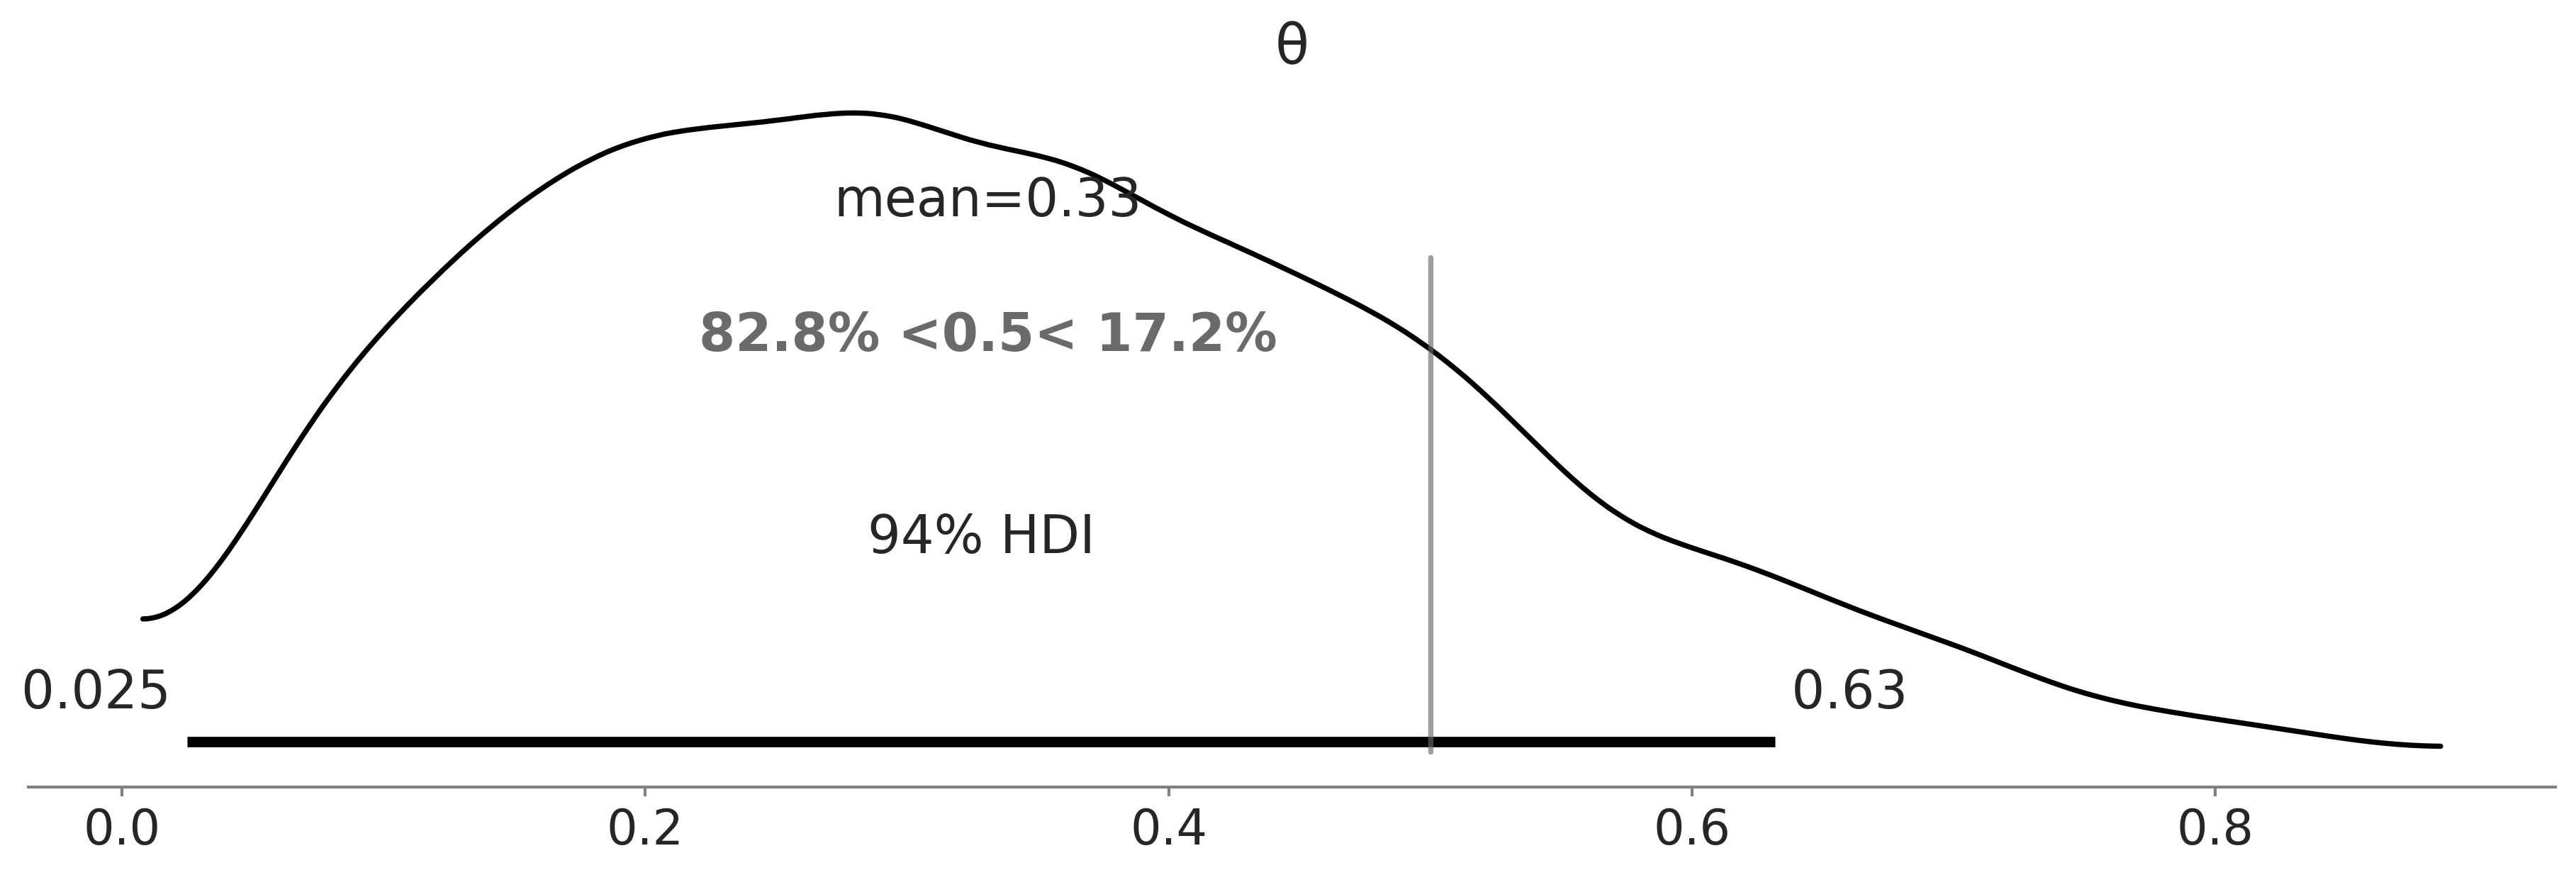

In [44]:
az.plot_posterior(idata, ref_val=0.5, figsize=(12, 4))

The function plots the posterior distribution of θ and compares it with a reference value (here, 0.5). The plot shows the density of plausible values for θ and annotates the proportion of posterior mass that lies below and above the reference value. This helps us directly assess how likely it is that θ is less than or greater than 0.5.

This plot indicates that about 80.3% of the posterior mass lies below 0.5, while 17.2% lies above 0.5. This means that, given the data, it is much more probable that θ is less than 0.5 than greater than 0.5. Interpreting this in the coin example, there is strong evidence that the probability of heads is below 0.5, suggesting the coin is biased toward tails rather than being fair.

In [45]:
grid = np.linspace(0, 1, 200)
θ_pos = idata.posterior['θ']
lossf_a = [np.mean(abs(i - θ_pos)) for i in grid]
lossf_b = [np.mean((i - θ_pos)**2) for i in grid]
np.argmin(lossf_a)

np.int64(62)

The code evaluates different possible estimates of θ on a grid between 0 and 1 and computes the expected loss under two loss functions: absolute loss and squared loss. For each candidate value i, it calculates how far i is from the posterior samples $\theta_{pos}$ The line `np.argmin(lossf_a)` finds the index of the grid value that minimizes the expected absolute loss, which corresponds to the posterior median.
Since the result is 64, it means the optimal estimate (under absolute loss) is the 64th point in the grid. Because the grid has 200 points between 0 
and 1, this corresponds approximately to $\theta \approx 64/199 \approx 0.32$.

Interpretation

This tells us that the value of θ that minimizes the average absolute error is around 0.32, which is the posterior median. In this coin example, this is a reasonable estimate of the probability of heads, and it is slightly below 0.5, reinforcing the earlier conclusion that the coin is likely biased toward tails.

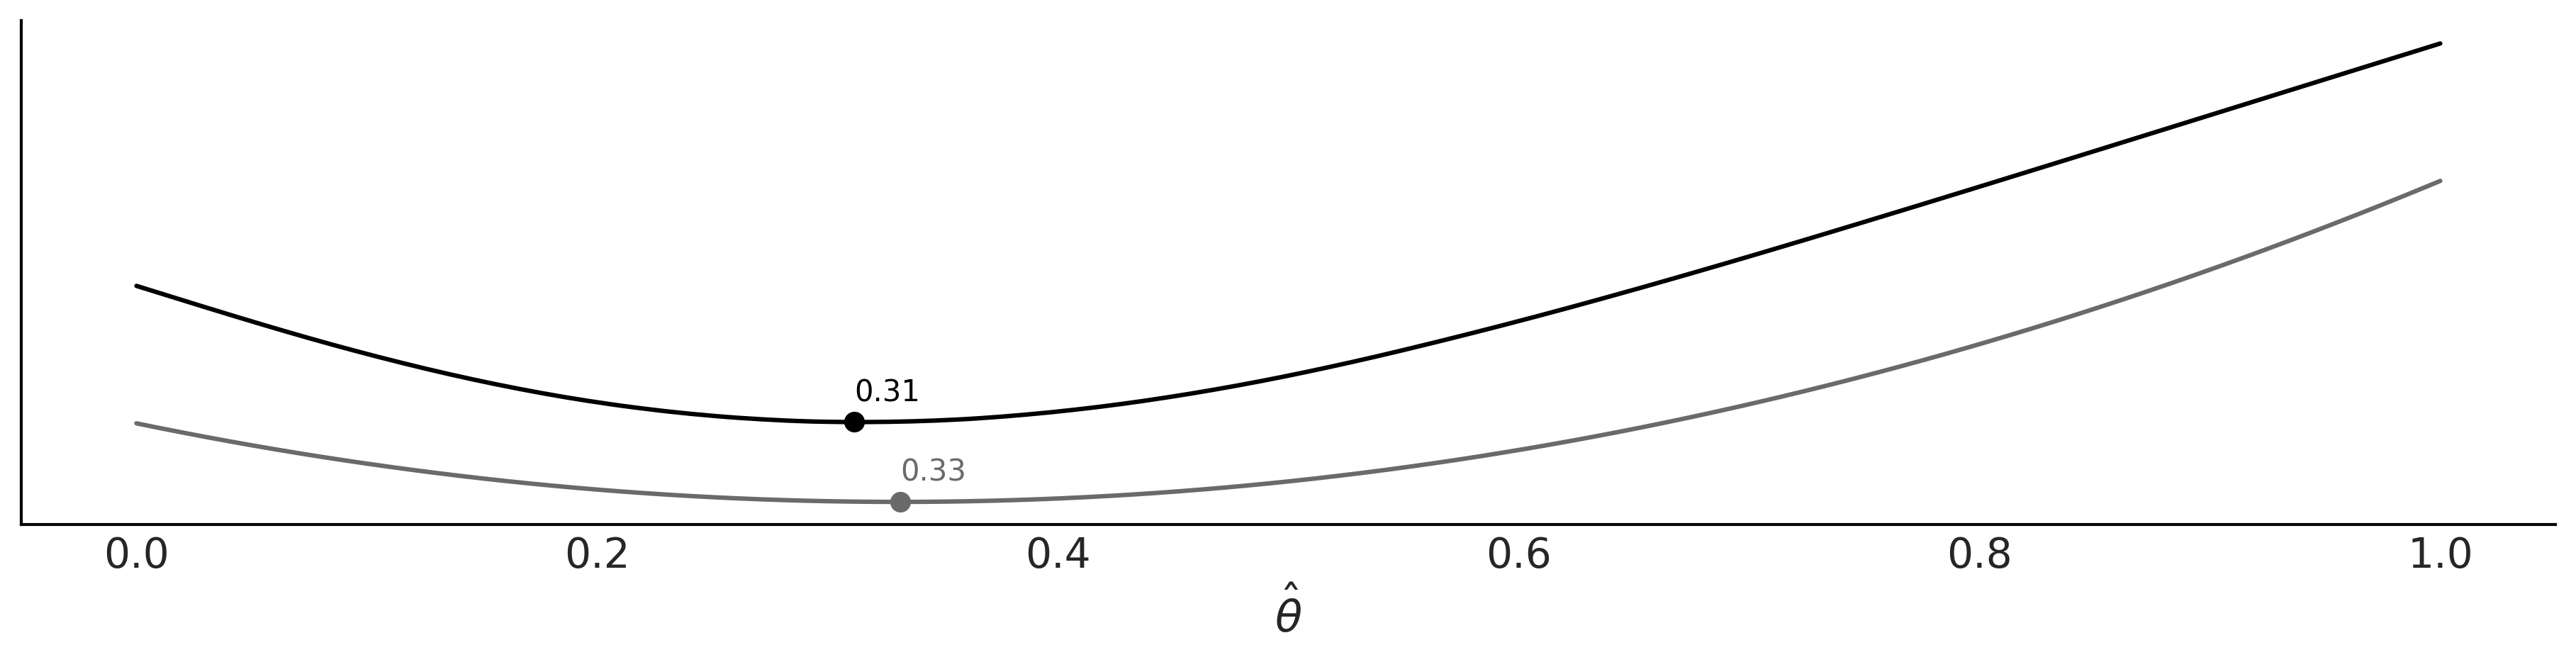

In [46]:
grid = np.linspace(0, 1, 200)
θ_pos = idata.posterior['θ']
lossf_a = [np.mean(abs(i - θ_pos)) for i in grid]
lossf_b = [np.mean((i - θ_pos)**2) for i in grid]
_, ax = plt.subplots(figsize=(12, 3))
for lossf, c in zip([lossf_a, lossf_b], ['C0', 'C1']):
    mini = np.argmin(lossf)
    ax.plot(grid, lossf, c)
    ax.plot(grid[mini], lossf[mini], 'o', color=c)
    ax.annotate('{:.2f}'.format(grid[mini]),
    (grid[mini], lossf[mini] + 0.03), color=c)

    ax.set_yticks([])
    ax.set_xlabel(r'$\hat \theta$')


This code uses the posterior samples of θ to evaluate which single value $\hat{\theta}$ would be the best estimate under different loss functions. For each candidate value on the grid (from 0 to 1), it computes the expected loss using the posterior samples obtained via MCMC, and then plots how this loss changes across possible estimates.

Interpretation

The two curves represent how “costly” each possible estimate $\hat{\theta}$ is:

- The absolute loss curve is minimized at a value that corresponds to the posterior median
- The squared loss curve is minimized at a value that corresponds to the posterior mean

The marked points on each curve show these optimal estimates. In your coin example, both optimal values lie below 0.5, indicating that the most reasonable estimates of the probability of heads are less than 0.5. This aligns with earlier results (posterior plot, HDI, and Bayes factor), all suggesting that the coin is likely biased toward tails. The fact that the two optimal estimates are close to each other also indicates that the posterior distribution is not highly skewed.

Overall, this result highlights an important idea in Bayesian decision theory: the “best” estimate depends on how we measure error, but in this case, all reasonable choices point to the same conclusion about θ.

Text(0.5, 0, '$\\hat \\theta$')

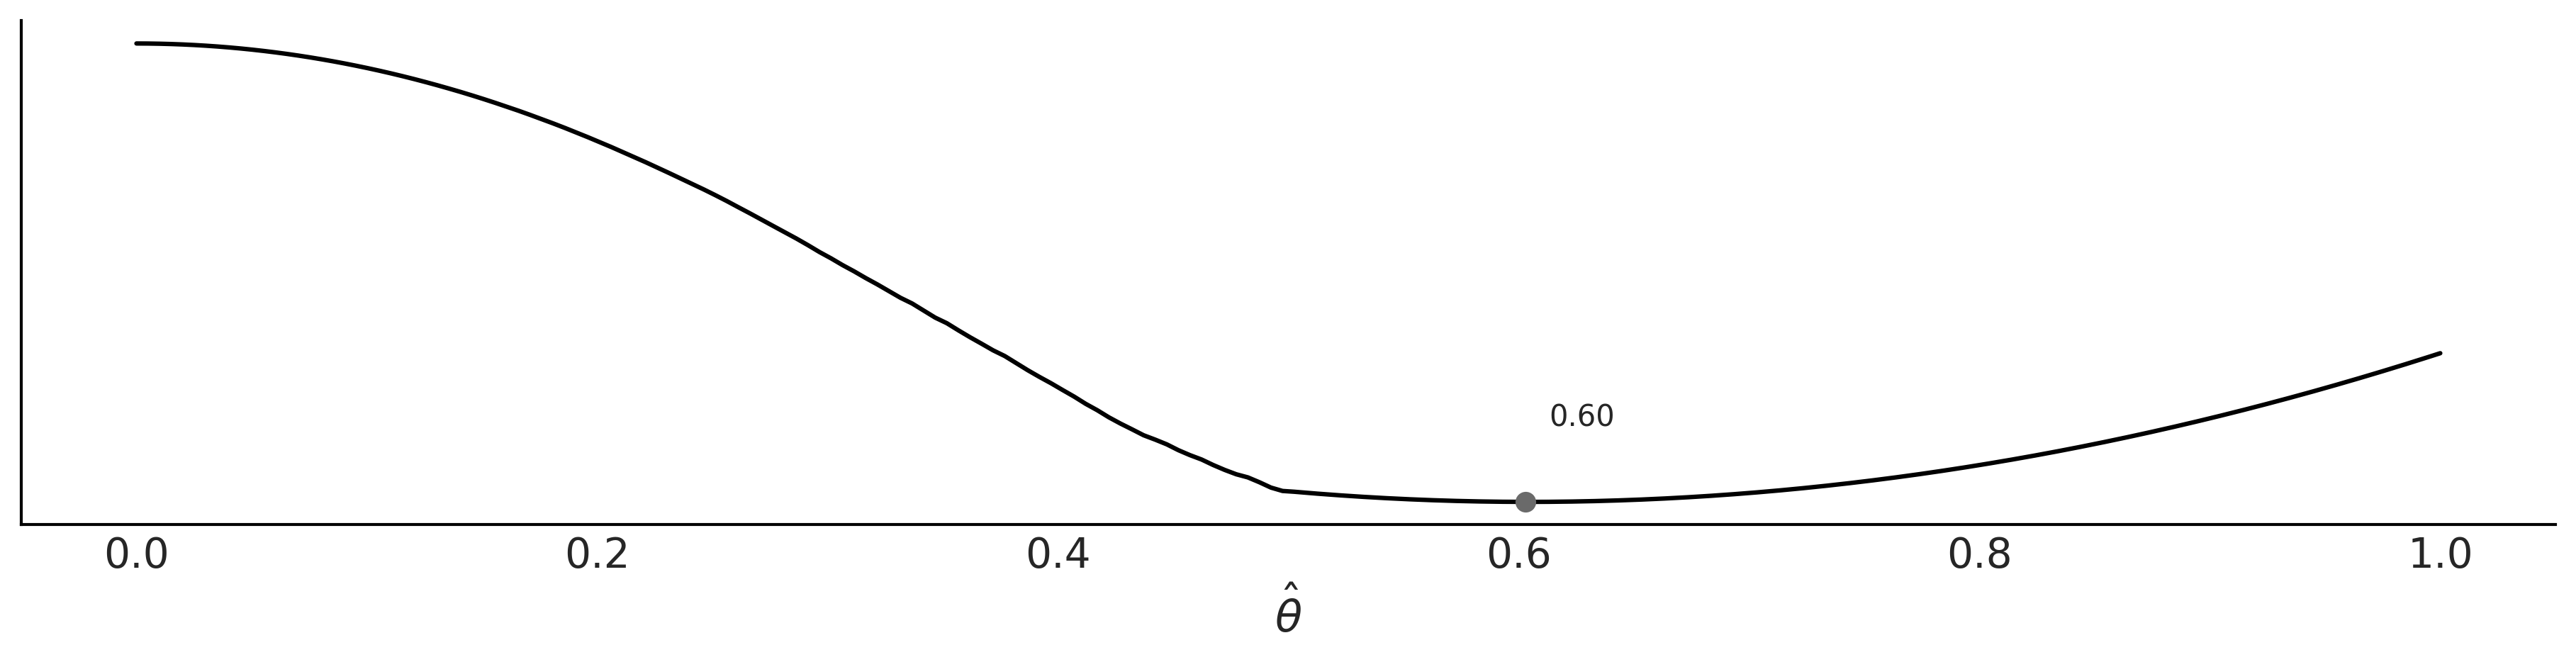

In [47]:
lossf = []
for i in grid:
    if i < 0.5:
        f = 1/np.median(θ_pos / np.abs(i**2 - θ_pos))
    else:
        f = np.mean((i - θ_pos)**2 + np.exp(-i)) - 0.25
    lossf.append(f)
mini = np.argmin(lossf)
_, ax = plt.subplots(figsize=(12, 3))
ax.plot(grid, lossf)
ax.plot(grid[mini], lossf[mini], 'o')
ax.annotate('{:.2f}'.format(grid[mini]),
(grid[mini] + 0.01, lossf[mini] + 0.1))
ax.set_yticks([])
ax.set_xlabel(r'$\hat \theta$')


The minimum of the loss occurs at $\hat{\theta} \approx 0.61$, which means that under this specific loss function, the optimal decision is to choose a value above 0.5. This differs from earlier results (such as the posterior mean, median, and overall probability mass), which suggested values below 0.5.

This difference arises because the loss function itself influences the decision. In particular, the part of the loss defined for values greater than 0.5 (including the $exp(−i)$ term and adjustment) makes errors in that region less costly compared to those below 0.5. As a result, even though the posterior distribution places more probability mass below 0.5, the decision rule shifts the optimal estimate toward 0.61.

**Is this a good or bad thing?**

This is not inherently good or bad. It depends on whether the loss function accurately reflects the real-world consequences of making errors.

If the loss function is well-designed and meaningful, then this result is correct and useful, because it aligns the decision with practical priorities.
If the loss function is arbitrary or unrealistic, then the result may be misleading, as it pushes the estimate away from where the data actually suggests.


This example highlights an important principle in Bayesian decision theory:

**The “best” estimate depends not only on the posterior distribution, but also on how we define the cost of errors.**

In this case, the custom loss function shifts the optimal estimate away from the bulk of the posterior, demonstrating that decision rules can override the central tendency of the data when they penalize errors asymmetrically.